# ISIS/CSM real-WAC reprojection spike: even/odd framestitch investigation

**Scope: this notebook stops after `framestitch`.** `isd_generate`/`mapproject`/`sat_sim` are
explicitly out of scope here -- they're future work once the even/odd-combination step below is
understood. This notebook exists to make each intermediate step's image directly visible inline
(previous progress on this was badly slowed by not being able to see intermediate steps), not to
reproduce the full reprojection pipeline.

Background: a prior spike (docs-only, see `../docs/data-sources.md`'s "ISIS3/CSM spike" section
and `../docs/history.md`'s Phase 12) got a real WAC swath reprojected onto the DEM via a genuine
ISIS3/CSM camera model end to end, but hit an unresolved blocker -- severe periodic striping at
framelet boundaries in `mapproject`'s output, confirmed structural/geometric, not an
illumination/AOI artifact. The working hypothesis is that the bug is introduced at the
`framestitch` step (combining the "even"/"odd" parity cubes into one), so this notebook steps
through exactly that far, with an image displayed after each step.

In [1]:
import numpy as np
import rasterio.windows

import trntest
from trntest import isis_wac, plotting

config = trntest.load_config()
print(f"edr_product={config.edr_product} edr_volume={config.edr_volume} target_frame_index={config.target_frame_index}")

edr_product=M1329714703CE edr_volume=LROLRC_0041C target_frame_index=440


This is `config.py`'s zero-argument default product (`M1329714703CE`, the same one the *first*
run of the prior spike used) -- no `dataclasses.replace` needed to target it. Its
`camera.boresight_rotation_k` is `+1` (non-mirrored pass), and the prior spike directly confirmed
`flip=false` is the visually-correct `framestitch` value for this product (the reverse, `flip=true`,
produced scrambled/banded garbage) -- see `docs/data-sources.md`. Hardcoded below rather than
recomputed, since recomputing it would mean furnishing SPICE kernels this notebook otherwise
doesn't need at all.

In [2]:
FLIP = False

## Step 0: ISIS reference data + EDR fetch

`isis_wac.ensure_isisdata()` is a one-time, lazily-skipped fetch (~5GB total: `base` +
`--no-kernels`, `lro` + `--no-kernels` -- `spiceinit web=yes` below covers the pointing/position
role that would otherwise need the much larger, un-flagged `base` download). `isis_wac.fetch_edr_img()`
pulls the EDR's own `.IMG` pixel data (not the `.xml` label the main demo pipeline already fetches,
and not the CDR `.IMG` `wac.py` uses) through the same `cache.fetch_lroc_file` mirror-and-skip
pattern as everything else in this repo.

In [3]:
isis_wac.ensure_isisdata(config)
edr = isis_wac.fetch_edr_img(config)
edr

EdrFetchResult(img_path=PosixPath('/workspace/cache/LRO-L-LROC-2-EDR-V1.0/LROLRC_0041C/DATA/ESM4/2019334/WAC/M1329714703CE.IMG'))

## Step 1: `lrowac2isis` -- split into even/odd x UV/VIS cubes

Splits the EDR into 4 cubes. The VIS cubes come out already band-separated (5 ISIS cube bands,
one per VIS filter) -- no manual byte-offset extraction needed, unlike `wac.py`'s approach against
the raw CDR. Only the VIS cubes matter for this investigation; the UV cubes are never touched
below.

In [4]:
split = isis_wac.run_lrowac2isis(edr, config)
split

Lrowac2IsisResult(uv_even=PosixPath('/workspace/scratch/isis_wac/M1329714703CE/M1329714703CE.uv.even.cub'), vis_even=PosixPath('/workspace/scratch/isis_wac/M1329714703CE/M1329714703CE.vis.even.cub'), uv_odd=PosixPath('/workspace/scratch/isis_wac/M1329714703CE/M1329714703CE.uv.odd.cub'), vis_odd=PosixPath('/workspace/scratch/isis_wac/M1329714703CE/M1329714703CE.vis.odd.cub'))

Raw split cubes, band 1 -- also doubles as the empirical check that `rasterio`/GDAL reads `.cub`
files directly (the prior spike found this true of ASP's own bundled GDAL; confirming it holds
here too).

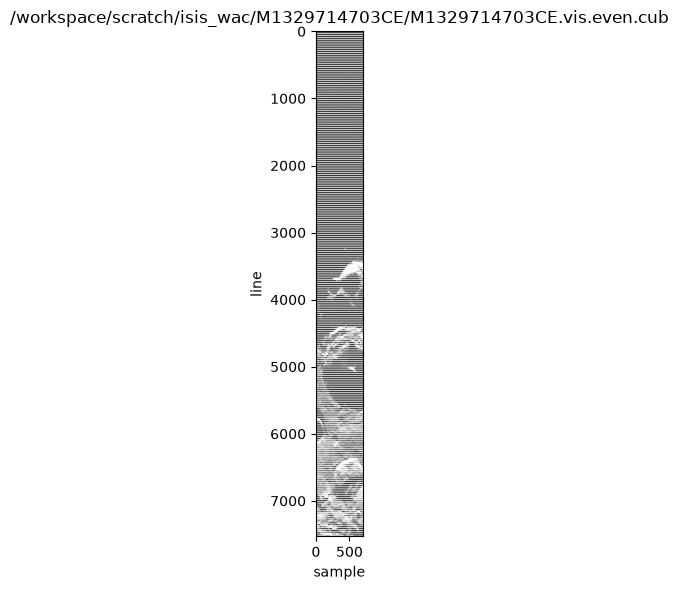

In [5]:
plotting.plot_raster(split.vis_even);

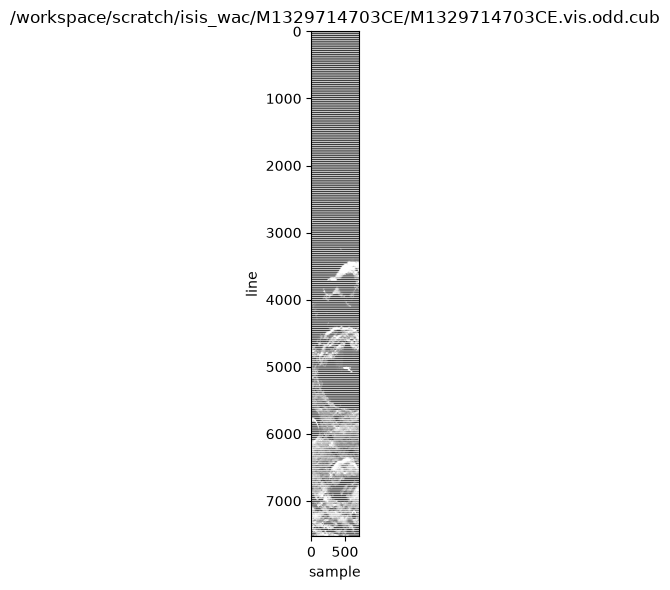

In [6]:
plotting.plot_raster(split.vis_odd);

## Step 2: `spiceinit web=yes` -- attach real SPICE geometry, zero local kernels required

Edits each cube's label in place (no new file, no re-display needed) -- confirmed in the prior
spike to work for WAC (not just NAC) with zero local kernel files fetched.

In [7]:
even_spice = isis_wac.run_spiceinit(split.vis_even, config)
odd_spice = isis_wac.run_spiceinit(split.vis_odd, config)

## Step 3: `lrowaccal` -- radiometric calibration

In [8]:
even_cal = isis_wac.run_lrowaccal(even_spice, config)
odd_cal = isis_wac.run_lrowaccal(odd_spice, config)

Calibrated even/odd cubes -- a visual baseline immediately before stitching, so any artifact that
shows up only *after* `framestitch` below can be attributed to the stitch itself rather than
something upstream.

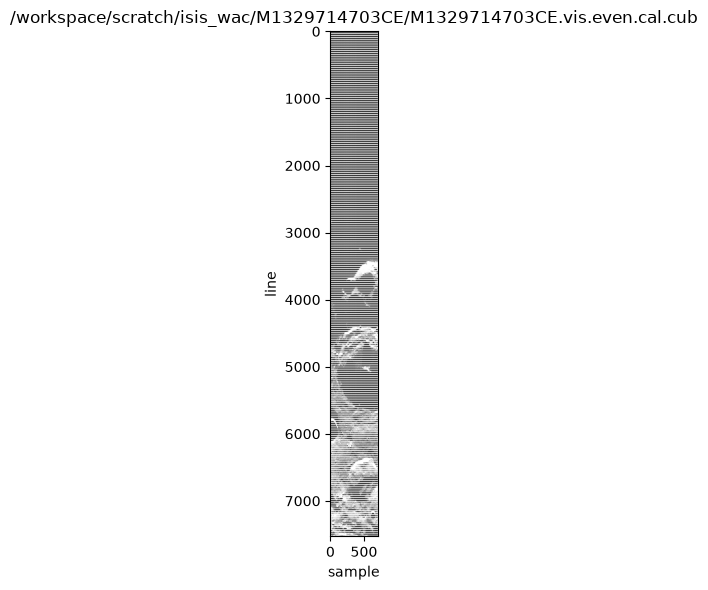

In [9]:
plotting.plot_raster(even_cal.cub_path);

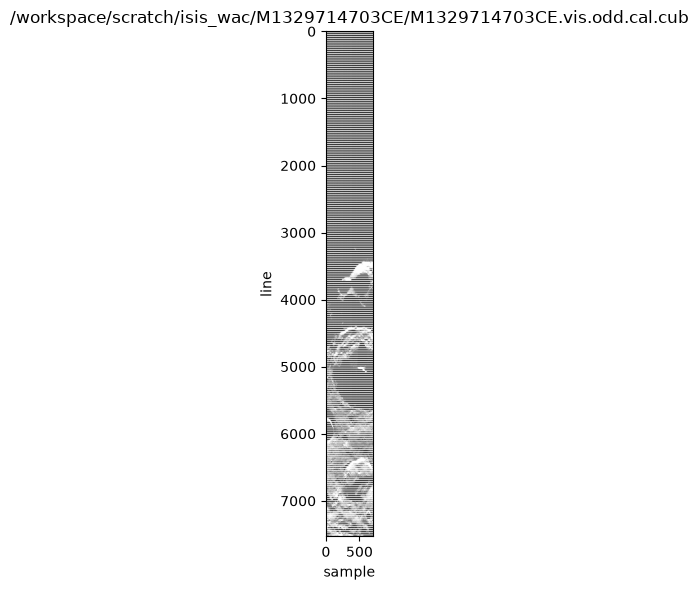

In [10]:
plotting.plot_raster(odd_cal.cub_path);

## Step 4: `framestitch` -- combine even + odd

This is the step under suspicion. `flip=False` per the hardcoded value above.

In [11]:
stitched = isis_wac.run_framestitch(even_cal, odd_cal, flip=FLIP, config=config)
stitched

FramestitchResult(cub_path=PosixPath('/workspace/scratch/isis_wac/M1329714703CE/M1329714703CE.vis.cal.stitched.cub'), flip=False)

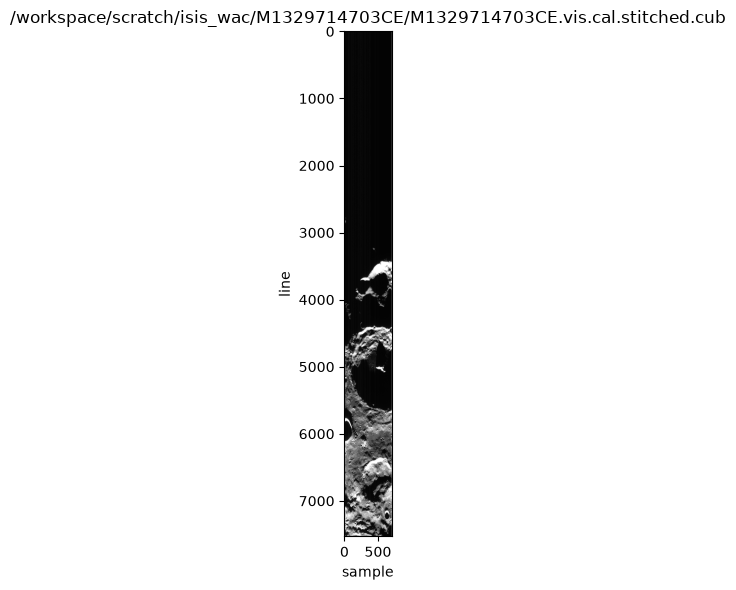

In [12]:
plotting.plot_raster(stitched.cub_path);

### Zoomed crop near framelet boundaries

The exact framelet period in *this* (post-`lrowac2isis`) cube's own line coordinates isn't
established -- the raw CDR's 78-lines/frame figure (`wac.LINES_PER_FRAME`) describes the
*pre*-TDI-extraction byte layout `wac.py` reads directly, not this already-TDI-processed ISIS
cube. Rather than guess a line range (the swath's early lines are the shadowed start the main
demo's own `select_dataset()` learned to avoid -- see `docs/history.md` Phase 2), pick the
window with real signal data-drivenly: read the whole band, find the `WINDOW_HEIGHT`-line span
with the highest mean value (a cheap proxy for "not near-empty/shadowed"), and crop there.

selected line window (peak mean signal): 6339:7339 of 7532


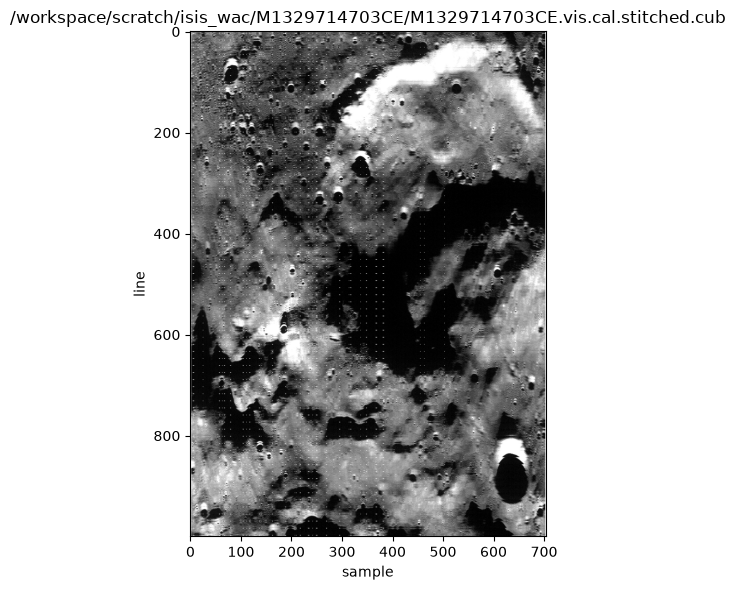

In [13]:
WINDOW_HEIGHT = 1000

full_band = plotting.read_raster_band(stitched.cub_path)

valid = plotting.valid_pixel_mask(full_band)
row_means = np.nan_to_num(np.nanmean(np.where(valid, full_band, np.nan), axis=1))
window_sums = np.convolve(row_means, np.ones(WINDOW_HEIGHT), mode="valid")
line_start = int(np.argmax(window_sums))
line_end = line_start + WINDOW_HEIGHT
print(f"selected line window (peak mean signal): {line_start}:{line_end} of {full_band.shape[0]}")

window = rasterio.windows.Window(col_off=0, row_off=line_start, width=704, height=WINDOW_HEIGHT)
plotting.plot_raster(stitched.cub_path, window=window);

## Observations

_(space to record what the seam actually looks like once this notebook has been run for real)_